In [1]:
# Imports

import os
from typing import Optional

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pdb
from cebed.utils import read_metadata
from cebed.datasets.utils import read_dataset_from_file

os.environ["CUDA_VISIBLE_DEVICES"]=""

2025-04-08 10:14:14.213394: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-08 10:14:14.262279: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-08 10:14:14.262324: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-08 10:14:14.263675: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-08 10:14:14.273763: I tensorflow/core/platform/cpu_feature_guar

In [2]:
data_path = "/home/CAMPUS/rghasemi/projects/MyPrivaterepo/CeBed/data_investigation"
assert os.path.isdir(data_path)

In [3]:
noisy_data = np.load("noisy_signals.npy")
noiseless_data = np.load("noiseless_signals.npy")


In [4]:
# Print basic information about the arrays
print(f"Noiseless signals shape: {noiseless_data.shape}")
print(f"Noisy signals shape: {noisy_data.shape}")
print(f"Noiseless signals dtype: {noiseless_data.dtype}")
print(f"Noisy signals dtype: {noisy_data.dtype}")


Noiseless signals shape: (32, 1, 1, 14, 612)
Noisy signals shape: (32, 1, 1, 14, 612)
Noiseless signals dtype: complex64
Noisy signals dtype: complex64


/tmp/ipykernel_1146510/4184809927.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbar


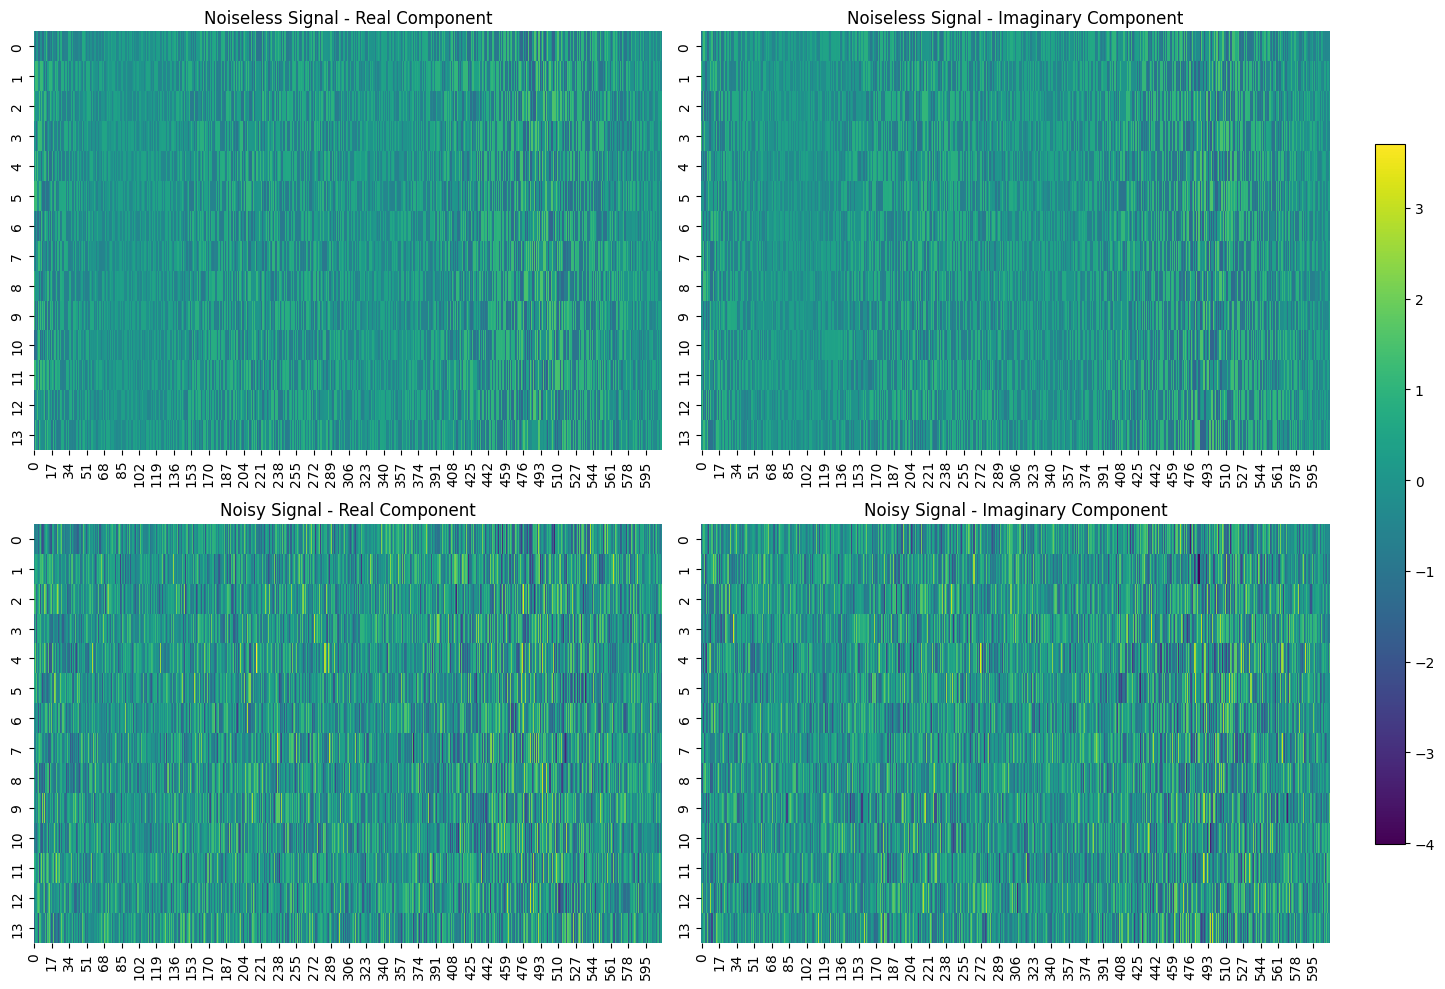

In [6]:

# Extract real and imaginary components
noiseless_real = np.real(noiseless_data)
noiseless_imag = np.imag(noiseless_data)
noisy_real = np.real(noisy_data)
noisy_imag = np.imag(noisy_data)



noiseless_real = noiseless_real[0].squeeze()
noiseless_imag = noiseless_imag[0].squeeze()
noisy_real = noisy_real[0].squeeze()
noisy_imag = noisy_imag[0].squeeze()

# Plot all components
# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Find the global min and max for consistent color scaling
vmin = min(noiseless_real.min(), noiseless_imag.min(), 
           noisy_real.min(), noisy_imag.min())
vmax = max(noiseless_real.max(), noiseless_imag.max(), 
           noisy_real.max(), noisy_imag.max())

# Plot heatmaps
sns.heatmap(noiseless_real, ax=axes[0,0], vmin=vmin, vmax=vmax, 
            cmap='viridis', cbar=False)
axes[0,0].set_title('Noiseless Signal - Real Component')

sns.heatmap(noiseless_imag, ax=axes[0,1], vmin=vmin, vmax=vmax, 
            cmap='viridis', cbar=False)
axes[0,1].set_title('Noiseless Signal - Imaginary Component')

sns.heatmap(noisy_real, ax=axes[1,0], vmin=vmin, vmax=vmax, 
            cmap='viridis', cbar=False)
axes[1,0].set_title('Noisy Signal - Real Component')

sns.heatmap(noisy_imag, ax=axes[1,1], vmin=vmin, vmax=vmax, 
            cmap='viridis', cbar=False)
axes[1,1].set_title('Noisy Signal - Imaginary Component')

# Add a shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbar
plt.show()